<a href="https://colab.research.google.com/github/annjgs/Fisica-Computacional/blob/Taller-6/Tarea_6_Integrales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%writefile ejercicio.cpp

#include <iostream>
#include <cmath>
#include<vector>
#include <iomanip>      //Control de salida para cifras significativas
#include <fstream>      //Para sacar datos a graficar


using namespace std;

double A = 2;
double b = 3;
double c = 4;

double F(double x) {         //funcion a integrar
 return A*exp(-(pow((x-b),2))/(2*(pow(c,2))));
}

double F_Integral(double x) {         // funcion integral exacta
    return A*c*sqrt(M_PI/2.0)*erf((x-b)/(sqrt(2.0)*c));
}


//Intervalo de integracion
int main(){
    int n = 1000;
    double inicio = 0;
    double fin = 20;
    double h = (fin - inicio) / (n);

    vector<double> x;

    for (int i = 0; i <= n; i++) {
        x.push_back(inicio + i*h);
    }

//resultados Integral real
double real = F_Integral(fin) - F_Integral(inicio);


//resultados integral cajas
double cajas = 0;
for (int i = 0; i < n; i++) {
    cajas += F(x[i])*h;
}


//resultados Integral trapecio
double trapecio = 0;
for (int i = 1; i < n; i++) {
    trapecio += 2*F(x[i])*(h/2);
}
trapecio = trapecio + F(inicio)*(h/2) + F(fin)*(h/2);


//resultados Itegral simpson
double simpson = 0;
double simpson_pares = 0;
double simpson_impares = 0;

for (int i = 1; i < n; i++){
    if (i % 2 == 0) {
        simpson_pares += F(x[i]);
    } else {
        simpson_impares += F(x[i]);
    }
}
simpson = F(inicio) + F(fin) + 2*simpson_pares + 4*simpson_impares;
simpson *= h/3;



cout << setprecision(15); //Colocar la mayor parte de las cifras para apreciar mejor el error

cout << real<<  " "
     << cajas << " "
     << trapecio << " "
     << simpson << endl;


ofstream archivo("datos.txt");

for (int i = 0; i <= n; i++) {
    archivo << x[i] << " " << F(x[i]) << endl;
}

archivo.close();

return 0;
}

Overwriting ejercicio.cpp


In [ ]:
!g++ ejercicio.cpp -o ejercicio

In [ ]:
!./ejercicio > resultado.txt

#Graficacion

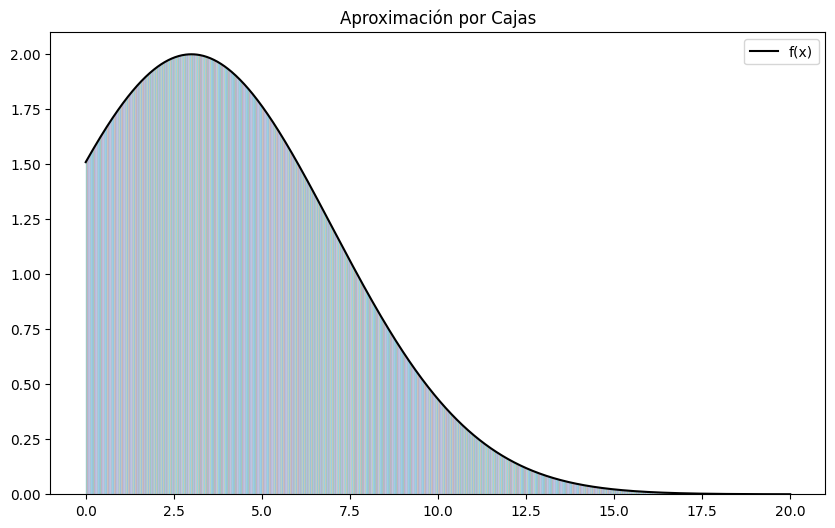

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
data = np.loadtxt("datos.txt")
x = data[:,0]
y = data[:,1]

plt.figure(figsize=(10,6))

# Curva real
plt.plot(x, y, label="f(x)", color="black")

# Área bajo la curva
plt.fill_between(x, y, alpha=0.3)

# Cajas (rectángulos)
for i in range(len(x)-1):
    plt.bar(x[i], y[i], width=(x[i+1]-x[i]), align='edge', alpha=0.2)

plt.title("Aproximación por Cajas")
plt.legend()
plt.show()






In [ ]:
%%writefile ejercicio_error.cpp

#include <iostream>
#include <cmath>
#include<vector>
#include <iomanip>      //Control de salida para cifras significativas
#include <fstream>      //Para sacar datos a graficar


using namespace std;

double A = 2;
double b = 3;
double c = 4;

double F(double x) {         //funcion a integrar
 return A*exp(-(pow((x-b),2))/(2*(pow(c,2))));
}

double F_Integral(double x) {         // funcion integral exacta
    return A*c*sqrt(M_PI/2.0)*erf((x-b)/(sqrt(2.0)*c));
}

vector<double> error_cajas;
vector<double> error_trapecio;
vector<double> error_simpson;
vector<double> hes;

//Intervalo de integracion
int main(){
    double inicio = 0;
    double fin = 20;


for (int n = 1; n <= 1000; n++) {
  if (n % 2 != 0) continue;

    double h = (fin - inicio) / (n);

    vector<double> x;

    for (int i = 0; i <= n; i++) {
        x.push_back(inicio + i*h);
    }

//resultados Integral real
double real = F_Integral(fin) - F_Integral(inicio);


//resultados integral cajas
double cajas = 0;
for (int i = 0; i < n; i++) {
    cajas += F(x[i])*h;
}


//resultados Integral trapecio
double trapecio = 0;
for (int i = 1; i < n; i++) {
    trapecio += 2*F(x[i])*(h/2);
}
trapecio = trapecio + F(inicio)*(h/2) + F(fin)*(h/2);


//resultados Itegral simpson
double simpson = 0;
double simpson_pares = 0;
double simpson_impares = 0;

for (int i = 1; i < n; i++){
    if (i % 2 == 0) {
        simpson_pares += F(x[i]);
    } else {
        simpson_impares += F(x[i]);
    }
}
simpson = F(inicio) + F(fin) + 2*simpson_pares + 4*simpson_impares;
simpson *= h/3;


error_cajas.push_back(abs(cajas - real));
error_trapecio.push_back(abs(trapecio - real));
error_simpson.push_back(abs(simpson - real));
hes.push_back(h);

}

cout << setprecision(15); //Colocar la mayor parte de las cifras para apreciar mejor el error

for (size_t k = 0; k < hes.size(); k++) {
    cout << hes[k] << " "
         << error_cajas[k] << " "
         << error_trapecio[k] << " "
         << error_simpson[k] << endl;
}
return 0;
}

Overwriting ejercicio_error.cpp


In [ ]:
!g++ ejercicio_error.cpp -o ejercicio_error

In [ ]:
!./ejercicio_error > resultado_error.txt

/tmp/ipykernel_728/2131107101.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("resultado_error.txt", delim_whitespace=True, header=None)


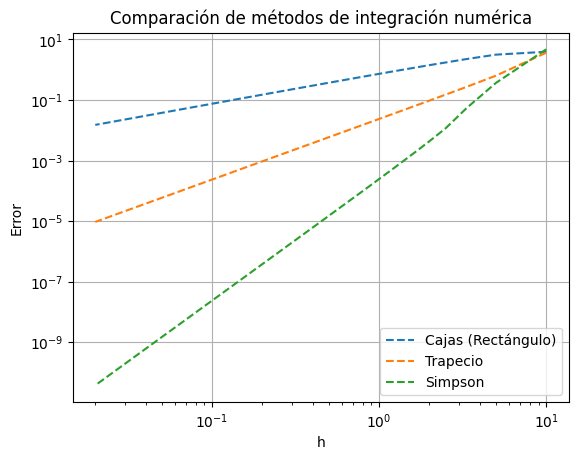

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("resultado_error.txt", delim_whitespace=True, header=None)
df.columns = ["h", "cajas", "trapecio", "simpson"]


plt.plot(df["h"], df["cajas"], label="Cajas (Rectángulo)", linestyle="--")
plt.plot(df["h"], df["trapecio"], label="Trapecio", linestyle="--")
plt.plot(df["h"], df["simpson"], label="Simpson", linestyle="--")


plt.xscale("log")
plt.yscale("log")

plt.grid()

plt.legend()
plt.xlabel("h")
plt.ylabel("Error")
plt.title("Comparación de métodos de integración numérica")

plt.show()

#Cuadratura Gauss-Legendre


In [ ]:
%%writefile ejercicio_3_cuadra.cpp

#include <iostream>
#include <cmath>
#include<vector>
#include <iomanip>      //Control de salida para cifras significativas


using namespace std;

double A = 2;
double b = 3;
double c = 4;

double F(double x) {         //funcion a integrar
 return A*exp(-(pow((x-b),2.0))/(2.0*(pow(c,2.0))));
}

double F_Integral(double x) {         // funcion integral exacta
    return A*c*sqrt(M_PI/2.0)*erf((x-b)/(sqrt(2.0)*c));
}

//cuadratura de Gauss
double gauss_legendre_3(double a, double b){
  double x[5] = {-0.9061798459,-0.5384693101,0.0,0.5384693101,0.9061798459};
  double w[5] = {0.2369268850,0.4786286705,0.5688888889,0.4786286705,0.2369268850};

  double suma = 0.0;
  for (int i = 0; i < 5; i++) {
   double t = ((b-a)/2.0) * x[i] + (a+b)/2.0;
    suma += w[i] * F(t);
  }
  return (b-a)/2.0 * suma;

}


int main(){
    double inicio = -1.0;      //Intervalo de integracion
    double fin = 1.0;

//resultados Integral real
double real = F_Integral(fin) - F_Integral(inicio);

//resultados Integral Cuadratura
double Gauss = gauss_legendre_3(inicio,fin);

double error = abs(real - Gauss);
double maximo = 0.08273104644;                        //valor maximo de la segunda derivada en el intervalo
double h = sqrt(error*24/(maximo*(fin-inicio)));
double rectángulos = (fin-inicio)/h;


cout << setprecision(15); //Colocar la mayor parte de las cifras para apreciar mejor el error

cout << real<<  " "
     << Gauss << endl;
cout << rectángulos << endl;

return 0;

}


Overwriting ejercicio_3_cuadra.cpp


In [ ]:
!g++ ejercicio_3_cuadra.cpp -o ejercicio_3_cuadra

In [ ]:
!./ejercicio_3_cuadra > resultado_cuadra.txt